# Exercise 2

In [ ]:
import math
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

## Part 1

In [148]:
def geomet(observations, p):
    data = np.random.uniform(0,1,observations)
    results = []
    for num in data:
        results.append(np.floor(np.log(num)/(np.log((1-p))))+1)
    return results

In [149]:
def pdf(p, x):
    return ((1-p)**(x-1)) * p

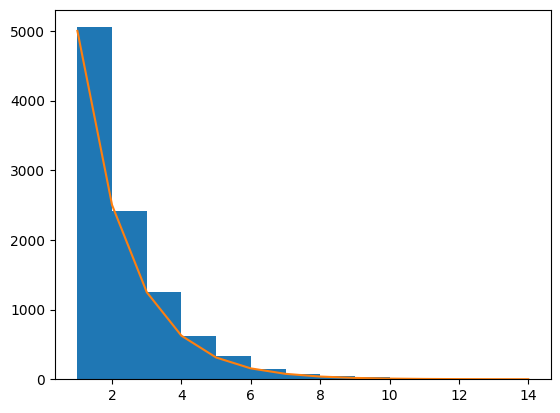

In [150]:
observations = 10000
p = 0.5

data_geomet = geomet(observations,p)

data_pdf = [pdf(p,x) * observations for x in range(1,int(max(data_geomet))+1)]

plt.hist(data_geomet,bins=np.arange(1, int(max(data_geomet))+1))
plt.plot(range(1,int(max(data_geomet))+1),data_pdf)
plt.show()

## Part 2

In [171]:
distribution = [7/48, 5/48, 1/8,1/16,1/4,5/16]

data_theory = [p * observations for p in distribution]

### a)

In [172]:
def direct(observations, distribution):
    U = np.random.uniform(0,1,observations)
    p_total = 0
    result_list = []

    for Ui in U:
        p_total = 0
        result = 1
        for i in range(len(distribution)):
            p_total += distribution[i]

            if Ui < p_total:
                result_list.append(result)
                break
            else:
                result +=1   

    return result_list

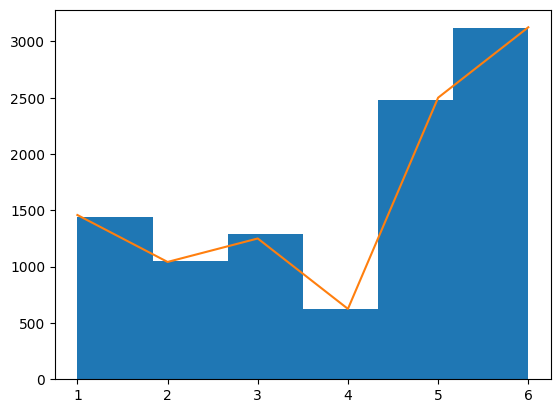

In [173]:
data_direct = direct(observations, distribution)

plt.hist(data_direct, bins=len(distribution))
plt.plot(range(1,len(distribution) + 1), data_theory)
plt.show()

### b)

In [174]:
def rejection(observations, distribution,eps=0.000001):
    c = eps+max(distribution)
    result_list = []

    while len(result_list) < observations:
        U = np.random.uniform(0,c)
        I = int(np.random.uniform(1,len(distribution)+1))
        
        if distribution[I-1] >= U/c:
            result_list.append(I)

    return result_list

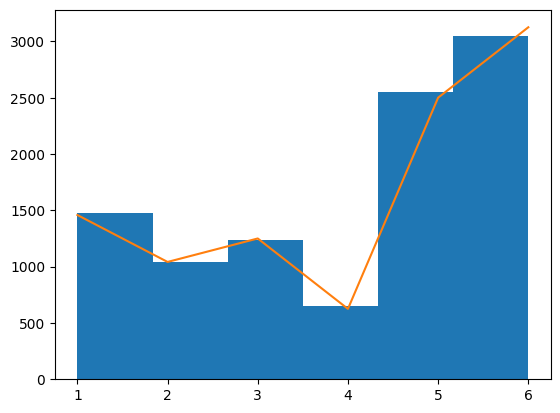

In [175]:
data_rejection = rejection(observations, distribution)

plt.hist(data_rejection, bins=len(distribution))
plt.plot(range(1,len(distribution) + 1), data_theory)
plt.show()

### c)

In [176]:
def alias(observations,distribution):
    L = [i for i in range(len(distribution))]
    F = [len(distribution) * p for p in distribution]
    
    G = []
    S = []

    result_list = []
    
    for i in range(len(F)):
        if F[i] >= 1:
            G.append(i)
        else:
            S.append(i)

    while(len(S) != 0):
        i = G[0]
        j = S[0]
        L[j] = i

        F[i] = F[i]-(1-F[j])
        if F[i] < 1:
            G.pop(0)
            S.append(i)
        S.pop(0)

    for i in range(observations):
        U = np.random.uniform(0,1)
        I = int(np.random.uniform(low=0,high = len(distribution)))

        if U <= F[I]:
            result_list.append(I+1)
        else:
            result_list.append(L[I+1])
            
    return result_list



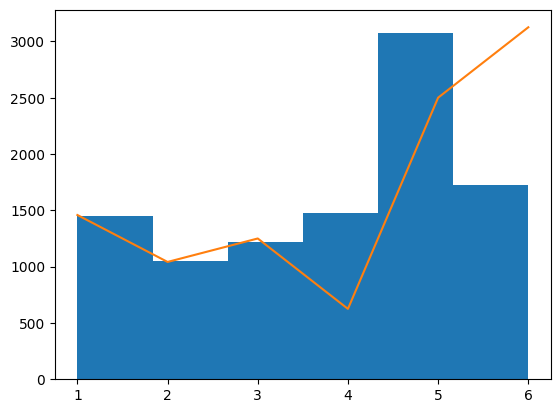

In [177]:
data_alias = alias(observations, distribution)

plt.hist(data_alias, bins=len(distribution))
plt.plot(range(1,len(distribution) + 1), data_theory)
plt.show()